In [1]:
import os

base_path = r"D:\Blood Clot\Dataset"
inner_folder = os.listdir(base_path)[0]

inner_path = os.path.join(base_path, inner_folder)

print(os.listdir(inner_path))


['Author Bios.docx', 'Normal', 'Sick']


In [2]:
path=inner_path

In [3]:
path

'D:\\Blood Clot\\Dataset\\extracted_data'

In [4]:
import os

# List the contents of the downloaded path
print(f"Contents of the downloaded dataset at {path}:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Contents of the downloaded dataset at D:\Blood Clot\Dataset\extracted_data:
extracted_data/
    Author Bios.docx
    Normal/
        Directory_1/
            1-short/
                series0030-Body/
                    img0001-24.9384.jpg
                    img0002-34.9384.jpg
                    img0003-44.9384.jpg
                    img0004-54.9384.jpg
                    img0005-64.9384.jpg
            2-long/
                series0029-Body/
                    img0001-26.6357.jpg
                    img0002-8.63881.jpg
                    img0003-35.8496.jpg
            33/
                1-short/
                    series0030-Body/
                        img0001-24.9384.jpg
                        img0002-34.9384.jpg
                        img0003-44.9384.jpg
                        img0004-54.9384.jpg
                        img0005-64.9384.jpg
                2-long/
                    series0029-Body/
                        img0001-26.6357.jpg
                        

# importing important library

In [5]:
import os

import cv2

import numpy as np

import tensorflow as tf

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, Dropout

from tensorflow.keras.models import Sequential

from sklearn.model_selection import train_test_split

In [6]:

import re

print("Matching Series (Images) with SR (Masks)...")

series_dict = {}
sr_dict = {}

# 1. Folders ko scan karke ID nikalo
for root, dirs, files in os.walk(path):
    folder_name = os.path.basename(root)
    
    # Check for Series folders (e.g., series0024-Body)
    if 'series' in folder_name:
        # Number nikalne ke liye regex: 'series' ke baad wale digits
        
        match = re.search(r'series(\d+)', folder_name)
        if match:
            # Leading zeros hata kar ID banaya (0024 -> 24)
            s_id = int(match.group(1))
            # Is folder ke andar ki images ka path store karo
            images = sorted([os.path.join(root, f) for f in files if f.endswith(('.jpg', '.png', '.jpeg'))])
            if images:
                series_dict[s_id] = images

    # Check for SR folders (e.g., SR_24)
    elif 'SR_' in folder_name:
        match = re.search(r'SR_(\d+)', folder_name)
        if match:
            sr_id = int(match.group(1))
            masks = sorted([os.path.join(root, f) for f in files if f.endswith(('.jpg', '.png', '.jpeg'))])
            if masks:
                sr_dict[sr_id] = masks

# 2. Common IDs dhundo (Jahan Image aur Mask dono maujood hain)
common_ids = sorted(list(set(series_dict.keys()) & set(sr_dict.keys())))

print(f"\nTotal Series Found: {len(series_dict)}")
print(f"Total SR (Masks) Found: {len(sr_dict)}")
print(f" Matched Pairs: {len(common_ids)}")

if len(common_ids) > 0:
    print(f"Example Match ID: {common_ids[0]}")
    print(f" - Image Count: {len(series_dict[common_ids[0]])}")
    print(f" - Mask Count: {len(sr_dict[common_ids[0]])}")
else:
    print("NO match found! Naming convention are different.")

Matching Series (Images) with SR (Masks)...

Total Series Found: 127
Total SR (Masks) Found: 114
 Matched Pairs: 114
Example Match ID: 1
 - Image Count: 3
 - Mask Count: 3


In [7]:

# Image Settings
IMG_SIZE = 128
data = []
labels = []


base_path = path  # Jo path aapne pehle download kiya tha

print("Scanning Normal and Sick folders...")

# Counters
normal_count = 0
sick_count = 0

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            full_path = os.path.join(root, file)
            
            # Labeling Logic: Path mein check karo ki wo 'Normal' folder mein hai ya 'Sick' mein
            if '/Normal' in full_path or '\\Normal' in full_path:
                label = 0  # 0 for Normal
                normal_count += 1
            elif '/Sick' in full_path or '\\Sick' in full_path:
                label = 1  # 1 for Sick (Blood Clot)
                sick_count += 1
            else:
                continue # Skip agar kisi aur folder mein hai
            
            try:
                # Image Read & Resize
                img_array = cv2.imread(full_path)
                if img_array is not None:
                    new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    data.append(new_array)
                    labels.append(label)
            except Exception as e:
                pass

print("Scanning Complete ")

Scanning Normal and Sick folders...
Scanning Complete 


In [8]:
# Data Convert to Numpy
X = np.array(data)
y = np.array(labels)

In [21]:
MAX_image=25000

X=X[:MAX_image]
y=y[:MAX_image]

In [22]:
print(f"\nData Loading Complete!")
print(f"Normal Images: {normal_count}")
print(f"Sick Images: {sick_count}")
print(f"Total Data Shape: {X.shape}")


Data Loading Complete!
Normal Images: 37565
Sick Images: 25861
Total Data Shape: (25000, 128, 128, 3)


In [15]:
print(X.dtype, X.shape)

uint8 (63426, 128, 128, 3)


In [9]:
from keras.layers import Rescaling 
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.metrics import  Precision, Recall,AUC

In [11]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#IMG_SIZE = 224  # agar upar define nahi kiya to

model = Sequential()

# 0) Normalization layer – ab yahin pe /255 ho raha hai
model.add(Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)))

# Layer 1
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten & Dense
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Overfitting rokne ke liye

# Output Layer (1 Neuron: 0 = Normal, 1 = Sick)
model.add(Dense(1, activation='sigmoid'))


C:\Users\hp\anaconda3\envs\dl_env\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',          
    
    patience=3,                   
    restore_best_weights=True,    
    verbose=1
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],  
    batch_size=16
)


Epoch 1/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 536s 167ms/step - accuracy: 0.8950 - loss: 0.2331 - val_accuracy: 0.9680 - val_loss: 0.0812
Epoch 2/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 526s 166ms/step - accuracy: 0.9683 - loss: 0.0825 - val_accuracy: 0.9807 - val_loss: 0.0493
Epoch 3/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 524s 165ms/step - accuracy: 0.9801 - loss: 0.0513 - val_accuracy: 0.9796 - val_loss: 0.0576
Epoch 4/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 523s 165ms/step - accuracy: 0.9864 - loss: 0.0376 - val_accuracy: 0.9886 - val_loss: 0.0292
Epoch 5/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 529s 167ms/step - accuracy: 0.9888 - loss: 0.0306 - val_accuracy: 0.9862 - val_loss: 0.0415
Epoch 6/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 528s 167ms/step - accuracy: 0.9908 - loss: 0.0261 - val_accuracy: 0.9872 - val_loss: 0.0414
Epoch 7/15
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 530s 167ms/step - accuracy: 0.9918 - loss: 0.0251 - val_accuracy: 0.9886 - val_loss: 0.0389
Epoch 7: early stopping
Restoring model weights from the end o

In [16]:
import matplotlib.pyplot as plt

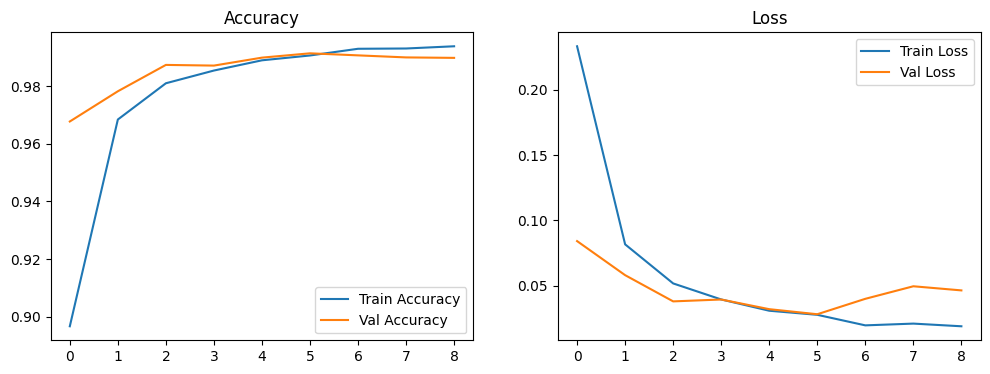

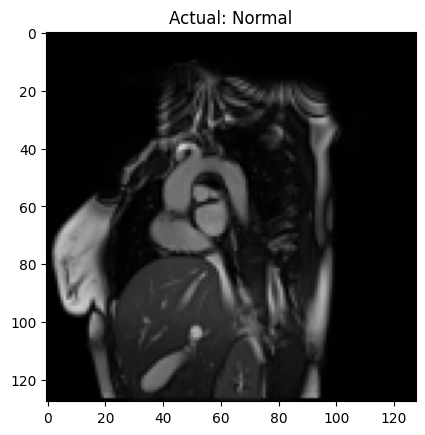

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Prediction: Normal
Confidence: 0.0000


In [17]:
# Accuracy Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

# Final Test on a Random Image
import random
idx = random.randint(0, len(X_test))
plt.imshow(X_test[idx])
plt.title(f"Actual: {'Sick' if y_test[idx]==1 else 'Normal'}")
plt.show()

pred = model.predict(X_test[idx].reshape(1, IMG_SIZE, IMG_SIZE, 3))
print(f"Prediction: {'Sick (Blood Clot Detected)' if pred[0][0] > 0.5 else 'Normal'}")
print(f"Confidence: {pred[0][0]:.4f}")

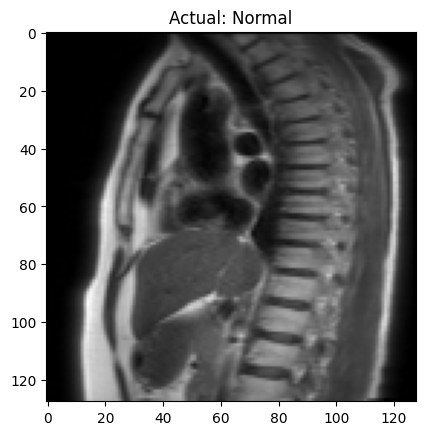

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: Normal
Confidence: 0.0000


In [18]:
# Final Test on a Random Image
import random
idx = random.randint(0, len(X_test))
plt.imshow(X_test[idx])
plt.title(f"Actual: {'Sick' if y_test[idx]==1 else 'Normal'}")
plt.show()

pred = model.predict(X_test[idx].reshape(1, IMG_SIZE, IMG_SIZE, 3))
print(f"Prediction: {'Sick (Blood Clot Detected)' if pred[0][0] > 0.5 else 'Normal'}")
print(f"Confidence: {pred[0][0]:.4f}")

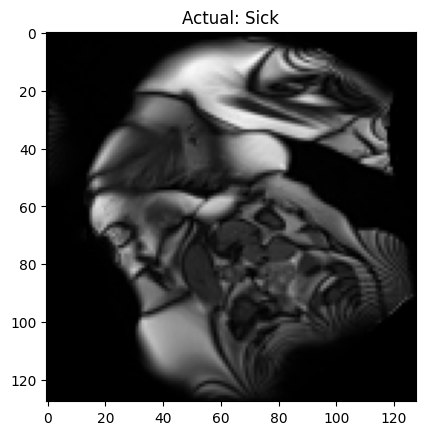

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Sick (Blood Clot Detected)
Confidence: 1.0000


In [19]:
# Final Test on a Random Image
import random
idx = random.randint(0, len(X_test))
plt.imshow(X_test[idx])
plt.title(f"Actual: {'Sick' if y_test[idx]==1 else 'Normal'}")
plt.show()

pred = model.predict(X_test[idx].reshape(1, IMG_SIZE, IMG_SIZE, 3))
print(f"Prediction: {'Sick (Blood Clot Detected)' if pred[0][0] > 0.5 else 'Normal'}")
print(f"Confidence: {pred[0][0]:.4f}")

In [20]:
import cv2
import numpy as np

# FIXED path
img_path = r"D:\Blood Clot\Dataset\extracted_data\Sick\Directory_18\SR_2\IM00001.jpg"

# Load and preprocess
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR→RGB for Keras models
img_resized = cv2.resize(img, (128, 128))

# Expand dims for model input
img_input = np.expand_dims(img_resized, axis=0)  # shape becomes (1, 128,128,3)

# Predict
pred = model.predict(img_input)
print("Raw prediction:", pred)

# Since sigmoid output → threshold 0.5
if pred[0][0] > 0.5:
    print("Prediction: Sick")
else:
    print("Prediction: Normal")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Raw prediction: [[0.99999166]]
Prediction: Sick


# Confusion matrics

397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step


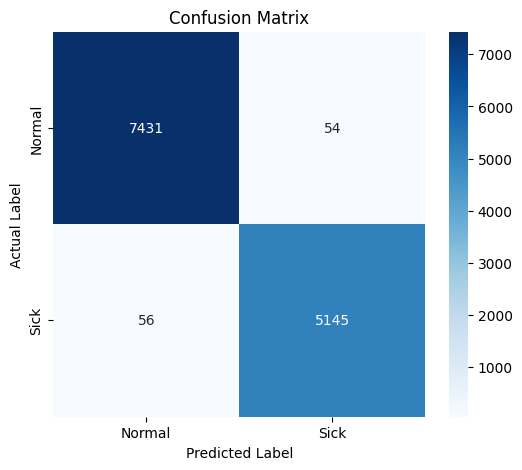


Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      7485
        Sick       0.99      0.99      0.99      5201

    accuracy                           0.99     12686
   macro avg       0.99      0.99      0.99     12686
weighted avg       0.99      0.99      0.99     12686



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Step 1: Predictions nikalein
# Sigmoid me value 0 se 1 ke beech aati hai (Probability)
y_pred_probs = model.predict(X_test)

# Step 2: Convert Probability to Labels (0 or 1)
# Agar value 0.5 se badi hai to 1 (Sick), nahi to 0 (Normal)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Step 3: Confusion Matrix Generate karein
cm = confusion_matrix(y_test, y_pred)

# Step 4: Sundar sa Graph Plot karein
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Sick'],  # Yahan apne labels likhein
            yticklabels=['Normal', 'Sick'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# Step 5: Text Report (Precision/Recall dekhne ke liye)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Sick']))

In [22]:
from sklearn.metrics import (
    
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [23]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)
print("AUC Score :", auc)


Precision : 0.9896133871898442
Recall    : 0.9892328398384926
F1 Score  : 0.989423076923077
AUC Score : 0.9994431470131189


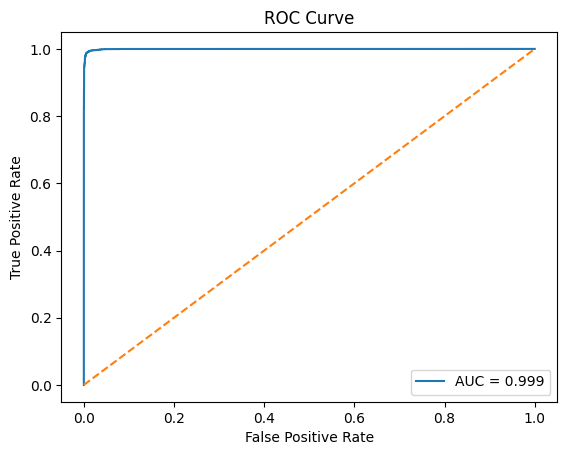

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Dice Score

In [19]:
def dice_score(y_true, y_pred):
    y_true = y_true.astype(np.bool_)
    y_pred = y_pred.astype(np.bool_)

    intersection = np.logical_and(y_true, y_pred).sum()
    return 2. * intersection / (y_true.sum() + y_pred.sum() + 1e-7)


# IoU Score

In [20]:
def iou_score(y_true, y_pred):
    y_true = y_true.astype(np.bool_)
    y_pred = y_pred.astype(np.bool_)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    return intersection / (union + 1e-7)


In [48]:
# Probabilities → labels
y_pred = (y_pred_probs > 0.5).astype(int)

dice = dice_score(y_test, y_pred)
iou = iou_score(y_test, y_pred)

print("Dice Similarity Coefficient:", dice)
print("Intersection over Union:", iou)


Dice Similarity Coefficient: 796.3339610297342
Intersection over Union: 0.24856959227500475


# DBN Algorithm

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. Restricted Boltzmann Machine (RBM) Class
class RBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hid, n_vis) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hid))
    
    def sample_from_p(self, p):
        return torch.relu(torch.sign(p - torch.rand(p.size())))

    def v_to_h(self, v):
        
        p_h = torch.sigmoid(torch.matmul(v, self.W.t()) + self.h_bias)
        return p_h, self.sample_from_p(p_h)

    def h_to_v(self, h):
        p_v = torch.sigmoid(torch.matmul(h, self.W) + self.v_bias)
        return p_v, self.sample_from_p(p_v)

    def contrastive_divergence(self, v, lr=0.01):
        # Positive phase
        pre_h1, h1 = self.v_to_h(v)
        # Negative phase
        pre_v2, v2 = self.h_to_v(h1)
        pre_h2, h2 = self.v_to_h(v2)
        
        # Update weights (Approximate Gradient)
        self.W.data += lr * (torch.matmul(h1.t(), v) - torch.matmul(h2.t(), v2)) / v.size(0)
        self.v_bias.data += lr * torch.mean(v - v2, dim=0)
        self.h_bias.data += lr * torch.mean(h1 - h2, dim=0)

# 2. Deep Belief Network (DBN) Class
class DBN(nn.Module):
    def __init__(self, input_size, hidden_layers, n_classes):
        super(DBN, self).__init__()
        self.rbms = nn.ModuleList()
        prev_size = input_size
        for h_size in hidden_layers:
            self.rbms.append(RBM(prev_size, h_size))
            prev_size = h_size
            
        self.classifier = nn.Linear(hidden_layers[-1], n_classes)

    def forward(self, x):
        # Flatten image
        x = x.view(x.size(0), -1)
        for rbm in self.rbms:
            x = torch.sigmoid(torch.matmul(x, rbm.W.t()) + rbm.h_bias)
        return self.classifier(x)

    def pretrain(self, train_loader, epochs=5, lr=0.01):
        print("Starting Unsupervised Pre-training...")
        for i, rbm in enumerate(self.rbms):
            print(f"Training RBM Layer {i+1}")
            for epoch in range(epochs):
                for batch_data, _ in train_loader:
                    v = batch_data.view(batch_data.size(0), -1)
                    # Pass through previous RBMs
                    for j in range(i):
                        _, v = self.rbms[j].v_to_h(v)
                    rbm.contrastive_divergence(v, lr=lr)
                print(f"Epoch {epoch+1}/{epochs} finished")

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

# Custom Dataset jo memory bachayega
class BloodClotDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images  # Ye original uint8 images hain (choti size)
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Image ko tabhi process karo jab zarurat ho
        img = self.images[idx].flatten().astype('float32') / 255.0
        label = self.labels[idx]
        return torch.tensor(img), torch.tensor(label).long()

# X_train aur X_test ko directly pass karein
train_ds = BloodClotDataset(X_train, y_train)
test_ds = BloodClotDataset(X_test, y_test)

# DataLoader (batch_size 32 ya 64 rakhein)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("DataLoader ready without Memory Error!")

DataLoader ready without Memory Error!


In [13]:
# --- RBM Layer Definition ---
class RBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hid, n_vis) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hid))
    
    def contrastive_divergence(self, v, lr=0.01):
        # Gibbs Sampling
        p_h1 = torch.sigmoid(torch.matmul(v, self.W.t()) + self.h_bias)
        h1 = torch.bernoulli(p_h1)
        p_v2 = torch.sigmoid(torch.matmul(h1, self.W) + self.v_bias)
        p_h2 = torch.sigmoid(torch.matmul(p_v2, self.W.t()) + self.h_bias)
        
        # Update Weights
        self.W.data += lr * (torch.matmul(p_h1.t(), v) - torch.matmul(p_h2.t(), p_v2)) / v.size(0)
        self.v_bias.data += lr * torch.mean(v - p_v2, dim=0)
        self.h_bias.data += lr * torch.mean(p_h1 - p_h2, dim=0)

# --- DBN Model ---
class BloodClotDBN(nn.Module):
    def __init__(self, input_size, hidden_layers, n_classes):
        super(BloodClotDBN, self).__init__()
        self.rbms = nn.ModuleList([RBM(input_size if i==0 else hidden_layers[i-1], h) 
                                   for i, h in enumerate(hidden_layers)])
        self.classifier = nn.Linear(hidden_layers[-1], n_classes)

    def forward(self, x):
        for rbm in self.rbms:
            x = torch.sigmoid(torch.matmul(x, rbm.W.t()) + rbm.h_bias)
        return self.classifier(x)

# Model Initialize (Input: 128*128*3 = 49152)
input_dim = 128 * 128 * 3
model = BloodClotDBN(input_size=input_dim, hidden_layers=[512, 256], n_classes=2)

# --- PHASE 1: PRE-TRAINING ---
print("--- Starting Unsupervised Pre-training ---")
for i, rbm in enumerate(model.rbms):
    print(f"Training RBM Layer {i+1}...")
    for epoch in range(5): # Chote data ke liye 5-10 epochs kaafi hain
        for batch_x, _ in train_loader:
            # Input ko previous layers se pass karna
            with torch.no_grad():
                v = batch_x
                for j in range(i):
                    v = torch.sigmoid(torch.matmul(v, model.rbms[j].W.t()) + model.rbms[j].h_bias)
            rbm.contrastive_divergence(v)
        print(f"Layer {i+1}, Epoch {epoch+1} complete.")

# --- PHASE 2: FINE-TUNING ---
print("\n--- Starting Supervised Fine-tuning ---")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)w211
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/20, Loss: {total_loss/len(train_loader):.4f}")

--- Starting Unsupervised Pre-training ---
Training RBM Layer 1...
Layer 1, Epoch 1 complete.
Layer 1, Epoch 2 complete.
Layer 1, Epoch 3 complete.
Layer 1, Epoch 4 complete.
Layer 1, Epoch 5 complete.
Training RBM Layer 2...
Layer 2, Epoch 1 complete.
Layer 2, Epoch 2 complete.
Layer 2, Epoch 3 complete.
Layer 2, Epoch 4 complete.
Layer 2, Epoch 5 complete.

--- Starting Supervised Fine-tuning ---
Epoch 1/20, Loss: 0.4022
Epoch 2/20, Loss: 0.2963
Epoch 3/20, Loss: 0.2657
Epoch 4/20, Loss: 0.2437
Epoch 5/20, Loss: 0.2520
Epoch 6/20, Loss: 0.2263
Epoch 7/20, Loss: 0.2168
Epoch 8/20, Loss: 0.2042
Epoch 9/20, Loss: 0.2035
Epoch 10/20, Loss: 0.2019
Epoch 11/20, Loss: 0.1912
Epoch 12/20, Loss: 0.1940
Epoch 13/20, Loss: 0.1976
Epoch 14/20, Loss: 0.2003
Epoch 15/20, Loss: 0.2018
Epoch 16/20, Loss: 0.1936
Epoch 17/20, Loss: 0.1992
Epoch 18/20, Loss: 0.1890
Epoch 19/20, Loss: 0.1923
Epoch 20/20, Loss: 0.1840


In [14]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()
all_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model(batch_x)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())

print("\nFinal Accuracy:", accuracy_score(y_test, all_preds))
print("\nClassification Report:\n", classification_report(y_test, all_preds, target_names=['Normal', 'Sick']))


Final Accuracy: 0.9087970991644332

Classification Report:
               precision    recall  f1-score   support

      Normal       0.88      0.98      0.93      7485
        Sick       0.96      0.81      0.88      5201

    accuracy                           0.91     12686
   macro avg       0.92      0.89      0.90     12686
weighted avg       0.91      0.91      0.91     12686



In [15]:
DBN_model=model

In [17]:
import torch
import torch.nn as nn

PATH="DBN_model.pth"
torch.save(DBN_model)

# GAN Algorithm

In [13]:
import torch
import torch.nn as nn

In [19]:
import tensorflow as tf
from tensorflow.keras import layers

def build_generator(latent_dim):
    model = tf.keras.Sequential([
        # 128x128 image ke liye hum 8x8 se start karenge
        layers.Dense(8 * 8 * 256, input_dim=latent_dim),
        layers.LeakyReLU(alpha=0.2),
        layers.Reshape((8, 8, 256)),

        # 16x16
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),

        # 32x32
        layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),

        # 64x64
        layers.Conv2DTranspose(64, (4,4), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),

        # 128x128
        layers.Conv2DTranspose(3, (4,4), strides=(2,2), padding='same', activation='tanh')
    ])
    return model

In [20]:
def build_discriminator(img_shape=(128, 128, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(64, (3,3), strides=(2,2), padding='same', input_shape=img_shape),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3), # Memory aur overfitting control ke liye

        layers.Conv2D(128, (3,3), strides=(2,2), padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [21]:
# Hyperparameters
latent_dim = 100
optimizer = tf.keras.optimizers.Adam(0.0002, 0.5)

# Build and Compile
discriminator = build_discriminator()
discriminator.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

generator = build_generator(latent_dim)

# Combined Model (GAN)
discriminator.trainable = False
gan_input = layers.Input(shape=(latent_dim,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(loss='binary_crossentropy', optimizer=optimizer)

# Training Function
import numpy as np

def train_gan(epochs, batch_size, X_train):
    # Data normalization to [-1, 1] for Tanh
    x_train = (X_train.astype('float32') - 127.5) / 127.5
    
    for epoch in range(epochs):
        # 1. Train Discriminator
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_imgs = X_train[idx]
        
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        fake_imgs = generator.predict(noise, verbose=0)
        
        d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
        
        # 2. Train Generator
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
        
        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | D Loss: {0.5 * np.add(d_loss_real, d_loss_fake)[0]} | G Loss: {g_loss}")

In [22]:
import numpy as np
import tensorflow as tf
import time

# 1. Dataset Taiyar Karna (Memory Friendly)
def prepare_dataset(X_train, batch_size):
    # Data ko [-1, 1] range mein normalize karein (GANs ke liye standard hai)
    x_train = (X_train.astype('float32') - 127.5) / 127.5
    
    dataset = tf.data.Dataset.from_tensor_slices(x_train)
    dataset = dataset.shuffle(buffer_size=1024).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# 2. Loss Functions & Optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# 3. Training Step (Custom Loop for better control)
@tf.function
def train_step(images, latent_dim):
    noise = tf.random.normal([images.shape[0], latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

# 4. Main Training Function
def train(dataset, epochs, latent_dim):
    for epoch in range(epochs):
        start = time.time()
        gen_loss_list = []
        disc_loss_list = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch, latent_dim)
            gen_loss_list.append(g_loss)
            disc_loss_list.append(d_loss)

        print(f'Epoch {epoch+1} finished. Time: {time.time()-start:.2f} sec')
        print(f'Gen Loss: {np.mean(gen_loss_list):.4f}, Disc Loss: {np.mean(disc_loss_list):.4f}')

# --- Kaise Run Karein ---
BATCH_SIZE = 16 # Memory issue hai isliye 16 ya 8 rakhein
LATENT_DIM = 100
EPOCHS = 50

# Pehle dataset prepare karein (Assuming x_train is your numpy array)
train_dataset = prepare_dataset(X_train, BATCH_SIZE)

# Train start karein
train(train_dataset, EPOCHS, LATENT_DIM)

MemoryError: Unable to allocate 9.29 GiB for an array with shape (50740, 128, 128, 3) and data type float32

In [23]:
import tensorflow as tf
import numpy as np

def prepare_dataset_low_mem(X_train, batch_size):
    # Step 1: Direct dataset banayein bina float32 mein convert kiye
    # X_train agar uint8 hai (0-255), toh ye RAM bachaayega
    dataset = tf.data.Dataset.from_tensor_slices(X_train)
    
    # Step 2: Mapping function jo sirf zarurat padne par normalize karega
    def normalize(image):
        # Convert to float32 and scale to [-1, 1] only for the current batch
        image = tf.cast(image, tf.float32)
        image = (image - 127.5) / 127.5
        return image

    # Pipeline setup
    dataset = dataset.shuffle(buffer_size=1000) # Buffer size chota rakha hai memory ke liye
    dataset = dataset.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# --- Implementation ---
BATCH_SIZE = 16 # Agar abhi bhi error aaye toh 8 kar dena
LATENT_DIM = 100

# Ab ye line MemoryError nahi degi kyunki hum sirf 'view' create kar rahe hain
train_dataset = prepare_dataset_low_mem(X_train, BATCH_SIZE)

# Ab aap training start kar sakte hain
# train(train_dataset, EPOCHS, LATENT_DIM)